In [1]:
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. DATASET SETUP
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
train_dir = os.path.join(path, 'seg_train/seg_train')
test_dir = os.path.join(path, 'seg_test/seg_test')

IMG_SIZE = (150, 150)
BATCH_SIZE = 32 # Reduce to 16 if you encounter OOM errors

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='categorical'
)
class_names = train_ds.class_names






Using Colab cache for faster access to the 'intel-image-classification' dataset.
Found 14034 files belonging to 6 classes.
Found 3000 files belonging to 6 classes.


In [2]:
# 2. MODEL FACTORIES
def get_alexnet():
    return models.Sequential([
        layers.Rescaling(1./255, input_shape=(150, 150, 3)),
        layers.Conv2D(96, 11, strides=4, padding='same', activation='relu'),
        layers.MaxPooling2D(3, strides=2),
        layers.Conv2D(256, 5, padding='same', activation='relu'),
        layers.MaxPooling2D(3, strides=2),
        layers.Conv2D(384, 3, padding='same', activation='relu'),
        layers.Conv2D(384, 3, padding='same', activation='relu'),
        layers.Conv2D(256, 3, padding='same', activation='relu'),
        layers.MaxPooling2D(3, strides=2),
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(4096, activation='relu'),
        layers.Dense(6, activation='softmax')
    ], name="AlexNet")

def get_vgg(model_type='VGG16'):
    cfg = {'VGG16': [(64,2), (128,2), (256,3), (512,3), (512,3)],
           'VGG19': [(64,2), (128,2), (256,4), (512,4), (512,4)]}[model_type]
    model = models.Sequential([layers.Rescaling(1./255, input_shape=(150, 150, 3))])
    for (f, n) in cfg:
        for _ in range(n): model.add(layers.Conv2D(f, 3, padding='same', activation='relu'))
        model.add(layers.MaxPooling2D(2, strides=2))
    model.add(layers.Flatten(),)
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dense(6, activation='softmax'))
    return model


In [3]:
# 3. TRAINING AND STORING MODELS
model_names = ["AlexNet", "VGG16", "VGG19"]
trained_models = {}
histories = {}

for name in model_names:
    print(f"\n--- Initializing and Training {name} ---")
    if name == "AlexNet": model = get_alexnet()
    else: model = get_vgg(name)

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    h = model.fit(train_ds, validation_data=val_ds, epochs=5) # 5 epochs for quick testing
    histories[name] = h.history
    trained_models[name] = model



--- Initializing and Training AlexNet ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 29s 49ms/step - accuracy: 0.5485 - loss: 1.1122 - val_accuracy: 0.6880 - val_loss: 0.8641
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.7137 - loss: 0.7817 - val_accuracy: 0.7607 - val_loss: 0.6631
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.7681 - loss: 0.6393 - val_accuracy: 0.7800 - val_loss: 0.6233
Epoch 4/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8022 - loss: 0.5550 - val_accuracy: 0.7957 - val_loss: 0.5725
Epoch 5/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.8223 - loss: 0.4960 - val_accuracy: 0.7957 - val_loss: 0.5727

--- Initializing and Training VGG16 ---
Epoch 1/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 213s 406ms/step - accuracy: 0.5434 - loss: 1.1289 - val_accuracy: 0.6530 - val_loss: 0.8512
Epoch 2/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 142s 322ms/step - accuracy: 0.6836 - loss: 0.8074 - val_accuracy: 0.7187 - val_loss: 0.7256
Epoch 3/5
439/439 ━━━━━━━━━━━━━━━━━━━━ 141s 320ms/st

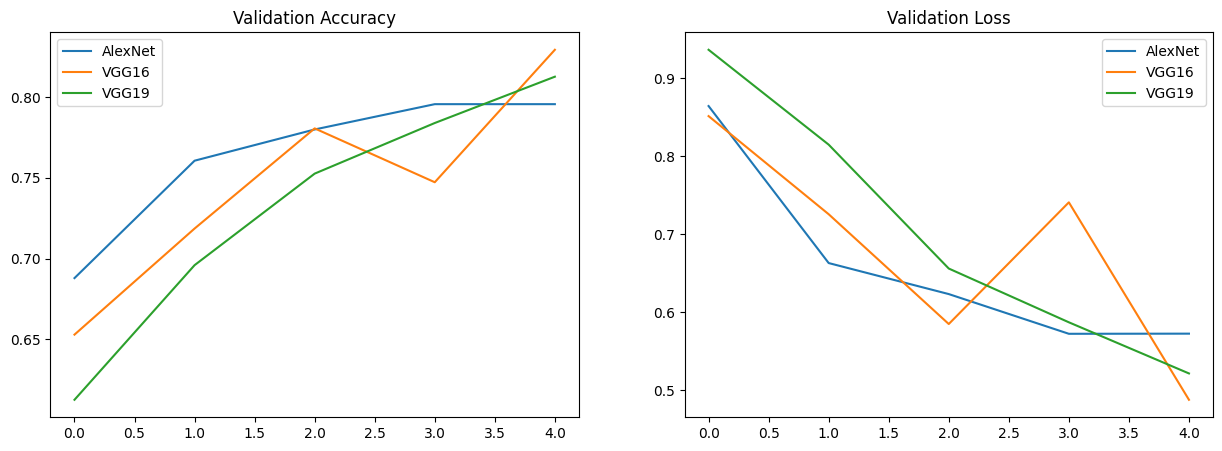

In [4]:
# 4. PERFORMANCE GRAPHS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for name in model_names:
    ax1.plot(histories[name]['val_accuracy'], label=name)
    ax2.plot(histories[name]['val_loss'], label=name)
ax1.set_title('Validation Accuracy'); ax1.legend()
ax2.set_title('Validation Loss'); ax2.legend()
plt.show()

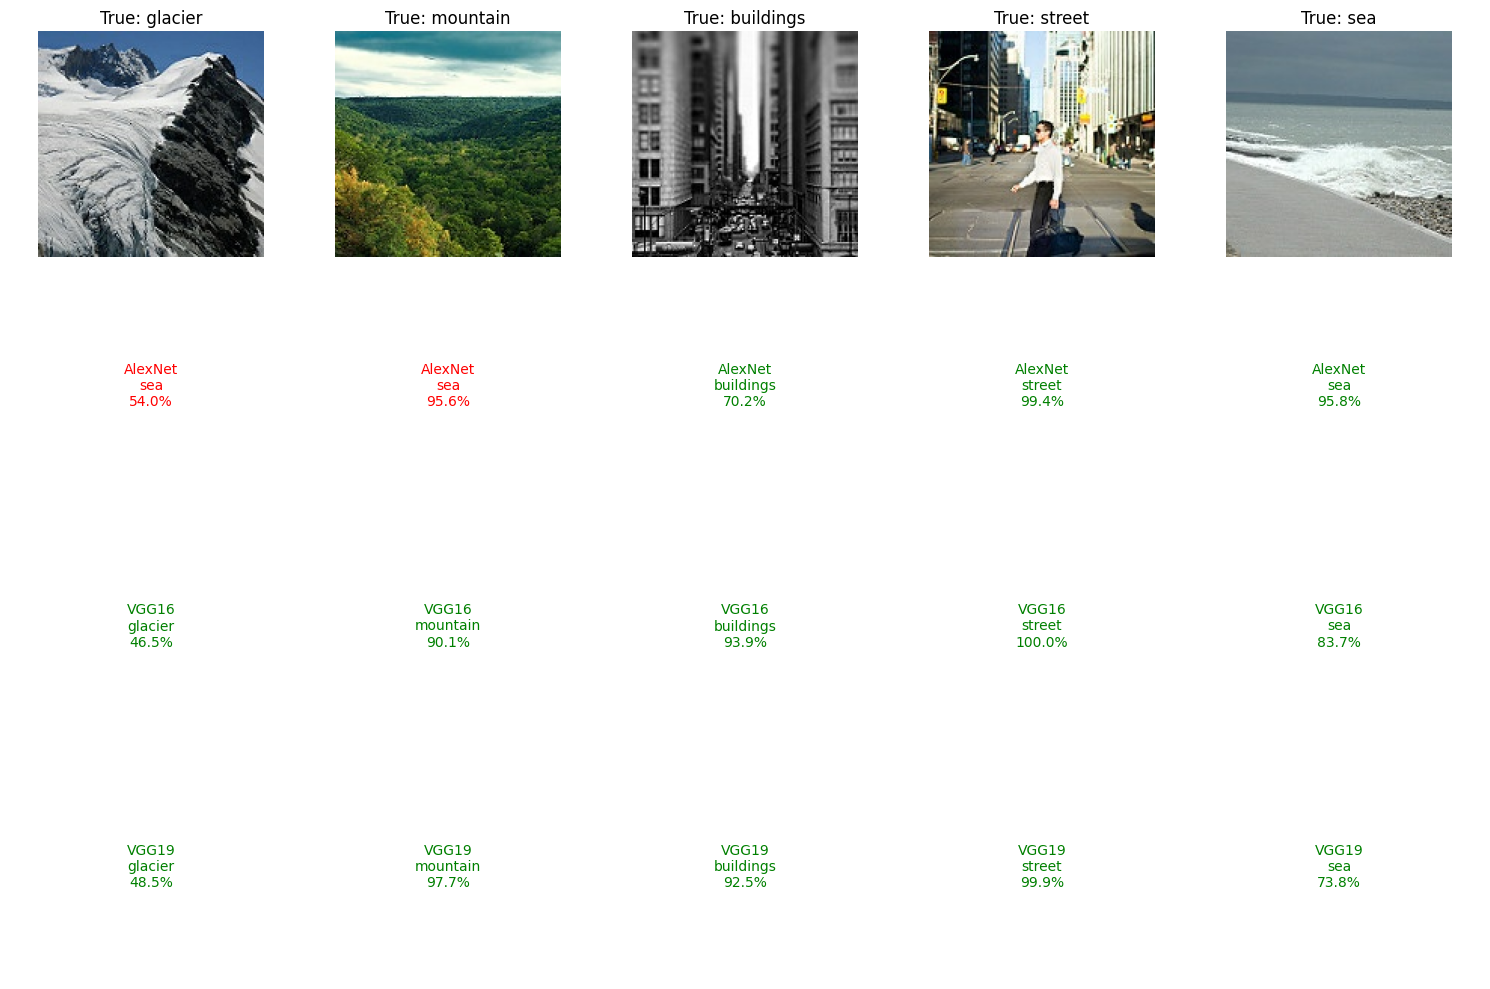

In [6]:

# 5. MULTI-IMAGE VISUALIZATION FOR EACH MODEL
def visualize_predictions(model_dict, dataset, num_images=5):
    # Get one batch of images
    for images, labels in dataset.take(1):
        plt.figure(figsize=(15, 10))
        for i in range(num_images):
            img = images[i].numpy()
            true_label = class_names[np.argmax(labels[i])]

            # Show original image
            ax = plt.subplot(len(model_dict) + 1, num_images, i + 1)
            plt.imshow(img.astype("uint8"))
            plt.title(f"True: {true_label}")
            plt.axis("off")

            # Show predictions for each model
            for m_idx, (name, model) in enumerate(model_dict.items()):
                pred_idx = (m_idx + 1) * num_images + (i + 1)
                ax = plt.subplot(len(model_dict) + 1, num_images, pred_idx)

                # Predict
                img_array = tf.expand_dims(img, 0)
                predictions = model.predict(img_array, verbose=0)
                pred_label = class_names[np.argmax(predictions)]
                confidence = np.max(predictions) * 100

                color = "green" if pred_label == true_label else "red"
                plt.text(0.5, 0.5, f"{name}\n{pred_label}\n{confidence:.1f}%",
                         fontsize=10, ha='center', va='center', color=color)
                plt.axis("off")
        plt.tight_layout()
        plt.show()

visualize_predictions(trained_models, val_ds)